In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config, generate_config_seq
from utils.vapour_reactor_utils import plot_reactor_solutions

from coupled.vapour_reactor import VapourReactor as Reactor

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30


In [3]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    data["HeatPipe"]["material"]["h_cond"] = 550

In [4]:
Ns = [[15, 15, 20], [15, 25, 20], [15, 35, 20], [15, 45, 20], [15, 60, 20]]
cfgs = generate_config_seq(data, Ns)

reactors = [Reactor(cfg) for cfg in cfgs]

solver = Solver(reactors)
solver.fsolve()

Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 1 ...
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 2 ...
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve messag

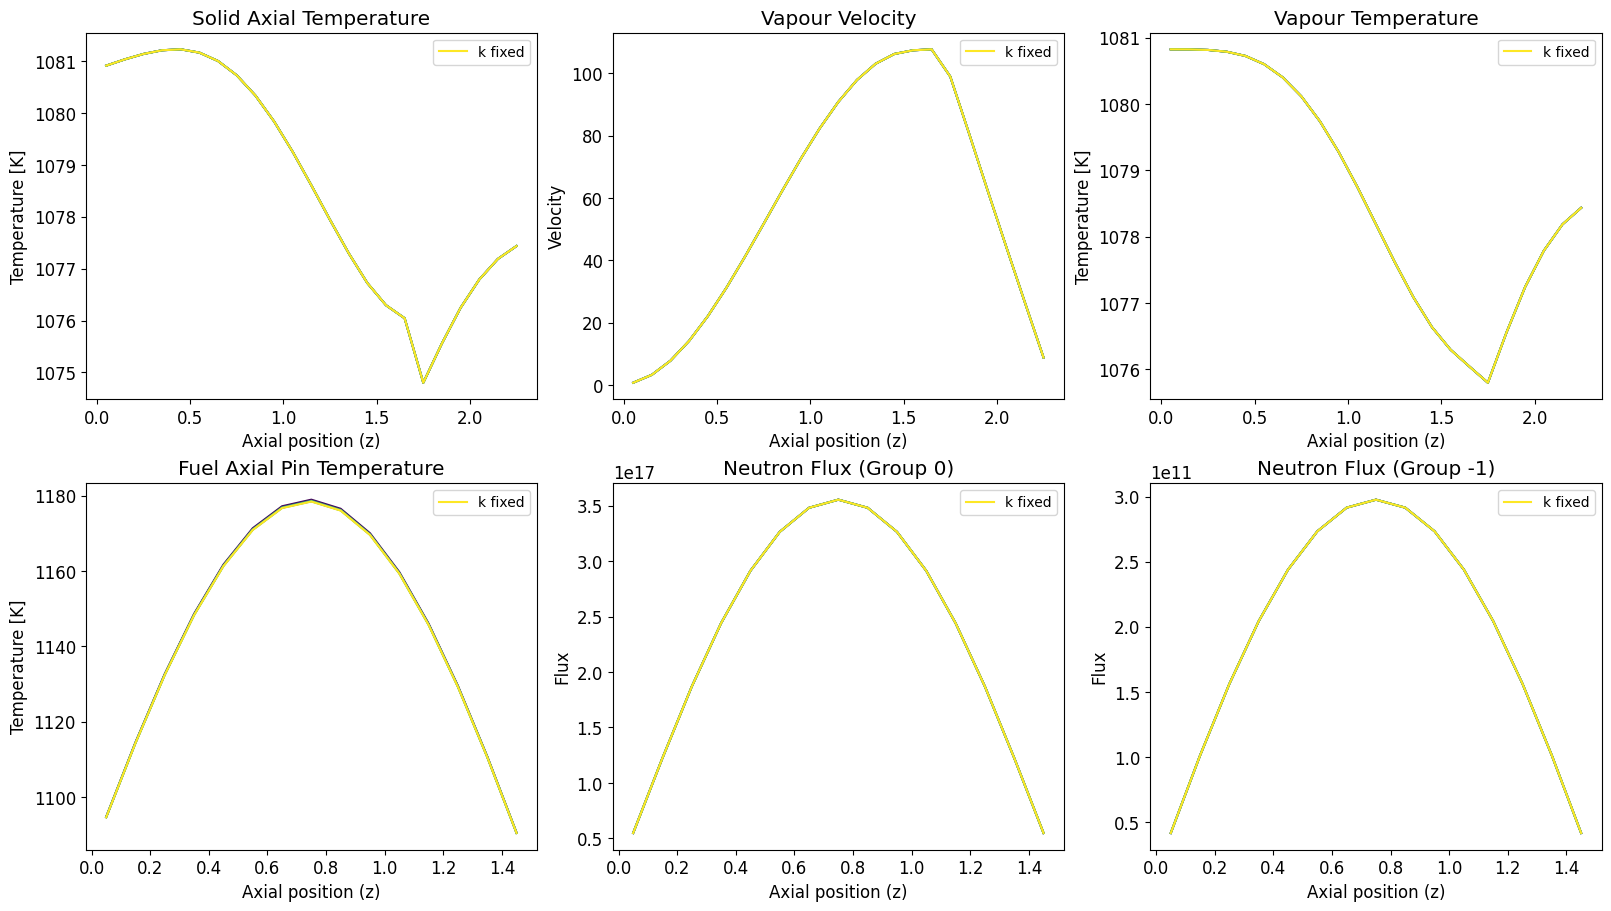

In [5]:
plot_reactor_solutions(solver)

In [6]:
Ns = [[15, 30, 20], [15, 45, 20]]
cfgs = generate_config_seq(data, Ns)

reactors = [Reactor(cfg) for cfg in cfgs]

solver = Solver(reactors)
solver.fsolve()

Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 1 ...
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 2 ...
fsolve message: The solution converged.


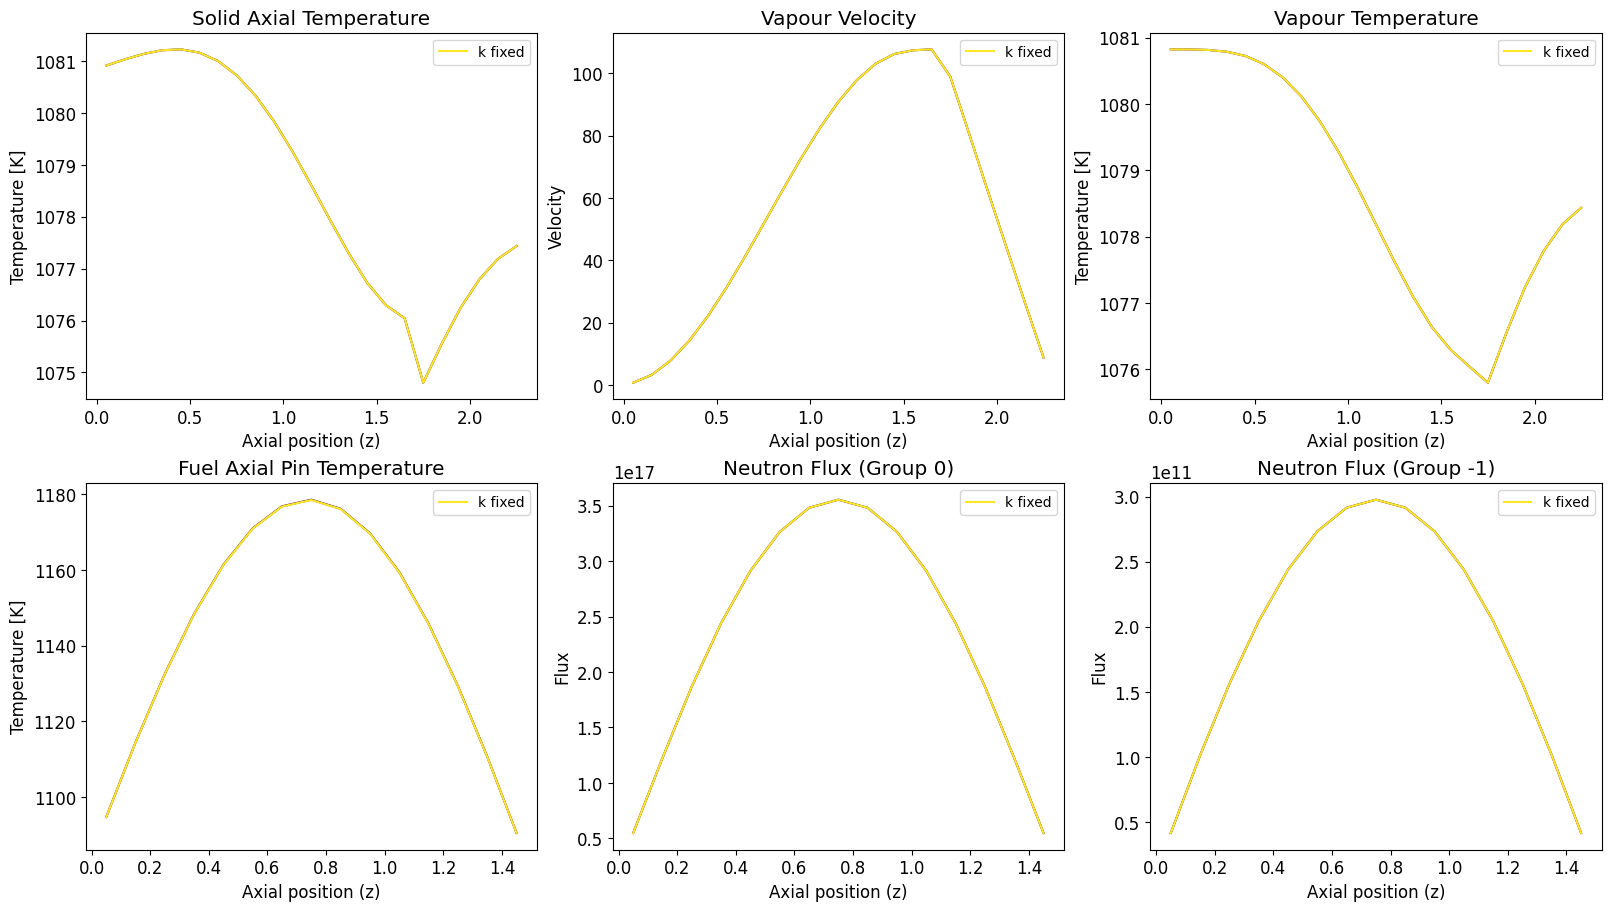

In [7]:
plot_reactor_solutions(solver)

In [8]:
import numpy as np

def print_reactor_convergence_report(solver, coarse_idx=0, fine_idx=-1):
    coarse = solver.components[coarse_idx]
    fine = solver.components[fine_idx]

    ((T_hp_coarse_all, _), T_fp_coarse, (_, k_coarse)) = solver.solutions[coarse_idx]
    ((T_hp_fine_all, _), T_fp_fine, (_, k_fine)) = solver.solutions[fine_idx]

    cfg_c = coarse.cfg_R
    cfg_f = fine.cfg_R

    fp_c = coarse.fuel_pin_thermal_model
    fp_f = fine.fuel_pin_thermal_model

    fuel_slice_c = slice(0, cfg_c.FP.mesh.N_fuel)
    fuel_slice_f = slice(0, cfg_f.FP.mesh.N_fuel)
    clad_slice_c = slice(cfg_c.FP.mesh.N_fuel + cfg_c.FP.mesh.N_gap, cfg_c.FP.mesh.N_R)
    clad_slice_f = slice(cfg_f.FP.mesh.N_fuel + cfg_f.FP.mesh.N_gap, cfg_f.FP.mesh.N_R)
    hp_wall_slice_c = slice(cfg_c.HP.mesh.N_R - cfg_c.HP.mesh.N_wall, cfg_c.HP.mesh.N_R)
    hp_wall_slice_f = slice(cfg_f.HP.mesh.N_R - cfg_f.HP.mesh.N_wall, cfg_f.HP.mesh.N_R)

    T_hp_coarse = T_hp_coarse_all[:cfg_c.HP.mesh.N_evap]
    T_hp_fine = T_hp_fine_all[:cfg_f.HP.mesh.N_evap]

    V_fuel_c = fp_c.Delta_V[fuel_slice_c]
    V_fuel_f = fp_f.Delta_V[fuel_slice_f]

    fuel_avg_c = np.sum(T_fp_coarse[:, fuel_slice_c] * V_fuel_c[None, :]) / (cfg_c.FP.mesh.N_Z * np.sum(V_fuel_c))
    fuel_avg_f = np.sum(T_fp_fine[:, fuel_slice_f] * V_fuel_f[None, :]) / (cfg_f.FP.mesh.N_Z * np.sum(V_fuel_f))

    clad_avg_c = np.mean(T_fp_coarse[:, clad_slice_c])
    clad_avg_f = np.mean(T_fp_fine[:, clad_slice_f])
    hp_wall_avg_c = np.mean(T_hp_coarse[:, hp_wall_slice_c])
    hp_wall_avg_f = np.mean(T_hp_fine[:, hp_wall_slice_f])

    fp_radial_avg_c = np.mean(T_fp_coarse, axis=0)
    fp_radial_avg_f = np.mean(T_fp_fine, axis=0)
    r_fp_c = fp_c.R
    r_fp_f = fp_f.R
    fp_radial_avg_c_on_f = np.interp(r_fp_f, r_fp_c, fp_radial_avg_c)
    fp_radial_diff = fp_radial_avg_f - fp_radial_avg_c_on_f

    hp_c = coarse.heat_pipe_thermal_model
    hp_f = fine.heat_pipe_thermal_model
    hp_radial_avg_c = np.mean(T_hp_coarse, axis=0)
    hp_radial_avg_f = np.mean(T_hp_fine, axis=0)
    r_hp_c = hp_c.R
    r_hp_f = hp_f.R
    hp_radial_avg_c_on_f = np.interp(r_hp_f, r_hp_c, hp_radial_avg_c)
    hp_radial_diff = hp_radial_avg_f - hp_radial_avg_c_on_f

    print(f"Coarse case: N_R_FP = {cfg_c.FP.mesh.N_R}, N_fuel = {cfg_c.FP.mesh.N_fuel}")
    print(f"Fine case:   N_R_FP = {cfg_f.FP.mesh.N_R}, N_fuel = {cfg_f.FP.mesh.N_fuel}")
    print()
    print(f"k_eff: coarse = {k_coarse:.6f}, fine = {k_fine:.6f}, delta = {k_fine - k_coarse:+.6e}")
    print(f"Fuel volume-averaged temperature [K]: coarse = {fuel_avg_c:.6f}, fine = {fuel_avg_f:.6f}, delta = {fuel_avg_f - fuel_avg_c:+.6e}")
    print(f"Fuel cladding average temperature [K]: coarse = {clad_avg_c:.6f}, fine = {clad_avg_f:.6f}, delta = {clad_avg_f - clad_avg_c:+.6e}")
    print(f"Heat pipe wall evaporator average temperature [K]: coarse = {hp_wall_avg_c:.6f}, fine = {hp_wall_avg_f:.6f}, delta = {hp_wall_avg_f - hp_wall_avg_c:+.6e}")
    print(f"Fuel radial-average profile max abs diff on fine grid [K]: {np.max(np.abs(fp_radial_diff)):.6e}")
    print(f"Fuel radial-average profile RMS diff on fine grid [K]: {np.sqrt(np.mean(fp_radial_diff**2)):.6e}")
    print(f"Heat pipe radial-average profile max abs diff on fine grid [K]: {np.max(np.abs(hp_radial_diff)):.6e}")
    print(f"Heat pipe radial-average profile RMS diff on fine grid [K]: {np.sqrt(np.mean(hp_radial_diff**2)):.6e}")

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs[0, 0].plot(r_fp_c, fp_radial_avg_c, label=f"N_R_FP = {cfg_c.FP.mesh.N_R}")
    axs[0, 0].plot(r_fp_f, fp_radial_avg_f, label=f"N_R_FP = {cfg_f.FP.mesh.N_R}")
    axs[0, 0].plot(r_fp_f, fp_radial_avg_c_on_f, "--", label=f"N_R_FP = {cfg_c.FP.mesh.N_R} interp.")
    axs[0, 0].set_title("Fuel Pin Radial Average Temperature")
    axs[0, 0].set_xlabel("Radius [m]")
    axs[0, 0].set_ylabel("Temperature [K]")
    axs[0, 0].grid(True, alpha=0.4)
    axs[0, 0].legend()

    axs[0, 1].plot(r_fp_f, fp_radial_diff)
    axs[0, 1].set_title("Fuel Pin: Fine - Interpolated Coarse")
    axs[0, 1].set_xlabel("Radius [m]")
    axs[0, 1].set_ylabel("Temperature Difference [K]")
    axs[0, 1].grid(True, alpha=0.4)

    axs[1, 0].plot(r_hp_c, hp_radial_avg_c, label=f"N_R_HP = {cfg_c.HP.mesh.N_R}")
    axs[1, 0].plot(r_hp_f, hp_radial_avg_f, label=f"N_R_HP = {cfg_f.HP.mesh.N_R}")
    axs[1, 0].plot(r_hp_f, hp_radial_avg_c_on_f, "--", label=f"N_R_HP = {cfg_c.HP.mesh.N_R} interp.")
    axs[1, 0].set_title("Heat Pipe Evaporator Radial Average Temperature")
    axs[1, 0].set_xlabel("Radius [m]")
    axs[1, 0].set_ylabel("Temperature [K]")
    axs[1, 0].grid(True, alpha=0.4)
    axs[1, 0].legend()

    axs[1, 1].plot(r_hp_f, hp_radial_diff)
    axs[1, 1].set_title("Heat Pipe: Fine - Interpolated Coarse")
    axs[1, 1].set_xlabel("Radius [m]")
    axs[1, 1].set_ylabel("Temperature Difference [K]")
    axs[1, 1].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()


In [9]:
print_reactor_convergence_report(solver)

ValueError: too many values to unpack (expected 2, got 3)

In [10]:
Ns = [[15, 20, 20], [25, 20, 20], [35, 20, 20], [45, 20, 20], [60, 20, 20]]
cfgs = generate_config_seq(data, Ns)

reactors = [Reactor(cfg) for cfg in cfgs]

solver = Solver(reactors)
solver.fsolve()

Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Mesh warning: N_R changed from 25 to 30
Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Mesh warning: N_R changed from 35 to 30
Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 1 ...
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 2 ...
fsolve

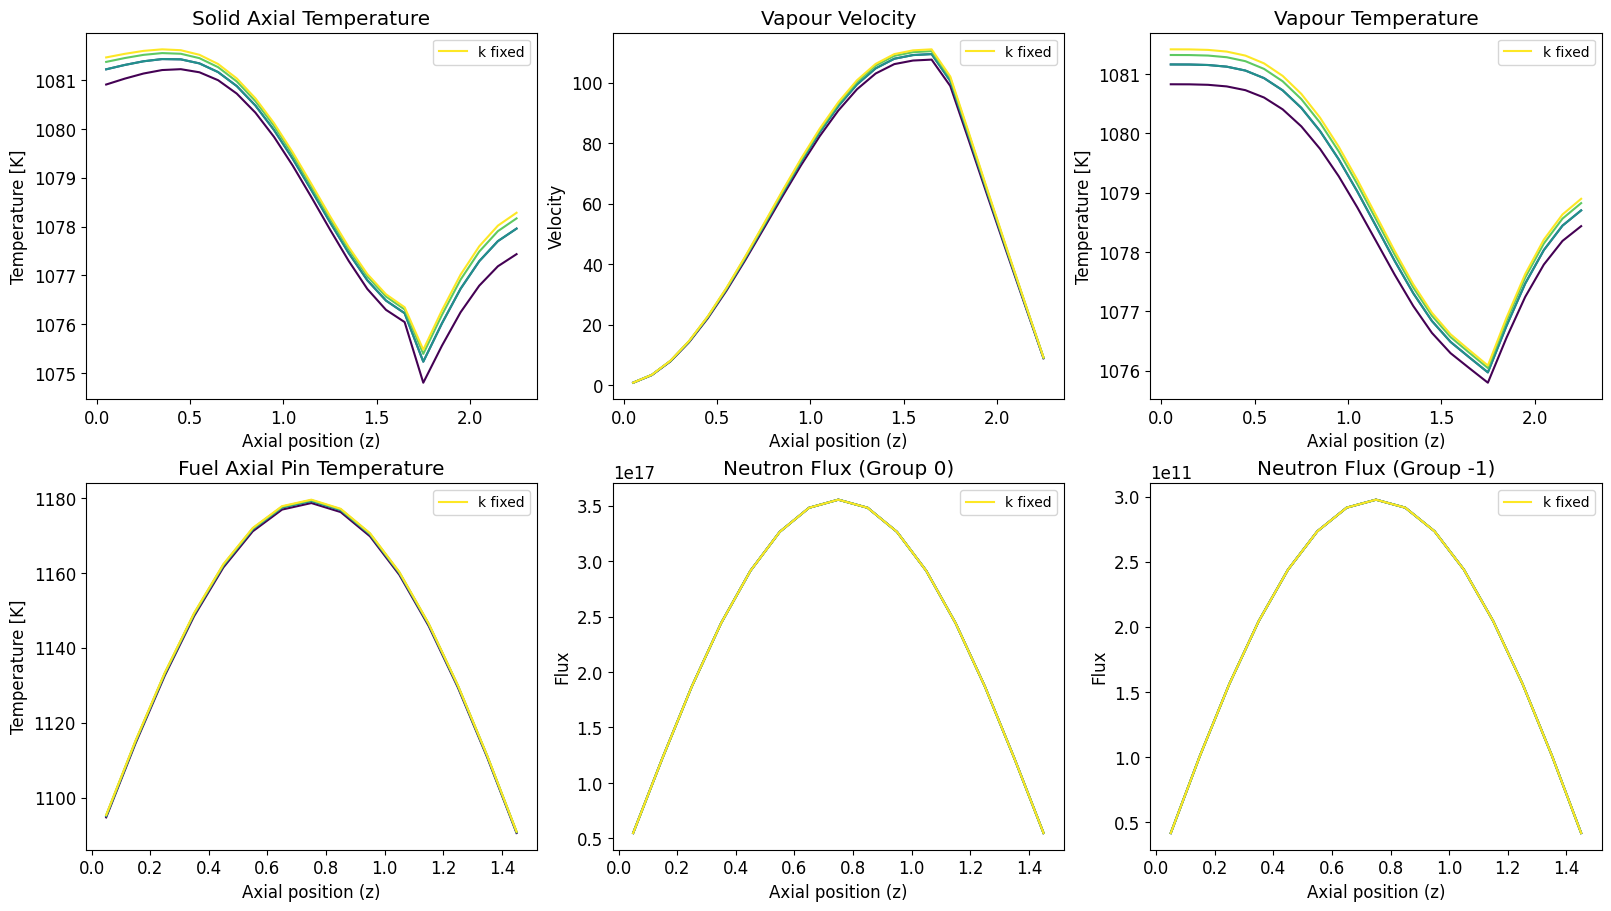

In [11]:
plot_reactor_solutions(solver)

In [12]:
Ns = [[15, 30, 20], [15, 30, 30], [15, 30, 40], [15, 30, 50], [15, 30, 60]]
cfgs = generate_config_seq(data, Ns)

reactors = [Reactor(cfg) for cfg in cfgs]

solver = Solver(reactors)
solver.fsolve()

Mesh warning: N_Z changed from 20 to 23
Mesh warning: Fuel pin N_Z changed from 9 to 15
Mesh warning: Neutronics N_Z changed from 9 to 15
Mesh warning: N_Z changed from 30 to 23
Mesh warning: Fuel pin N_Z changed from 13 to 15
Mesh warning: Neutronics N_Z changed from 13 to 15
Mesh warning: N_Z changed from 40 to 46
Mesh warning: Fuel pin N_Z changed from 18 to 30
Mesh warning: Neutronics N_Z changed from 18 to 30
Mesh warning: N_Z changed from 50 to 46
Mesh warning: Fuel pin N_Z changed from 22 to 30
Mesh warning: Neutronics N_Z changed from 22 to 30
Mesh warning: N_Z changed from 60 to 69
Mesh warning: Fuel pin N_Z changed from 27 to 45
Mesh warning: Neutronics N_Z changed from 27 to 45
Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 1 ...
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 2 ...
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolv

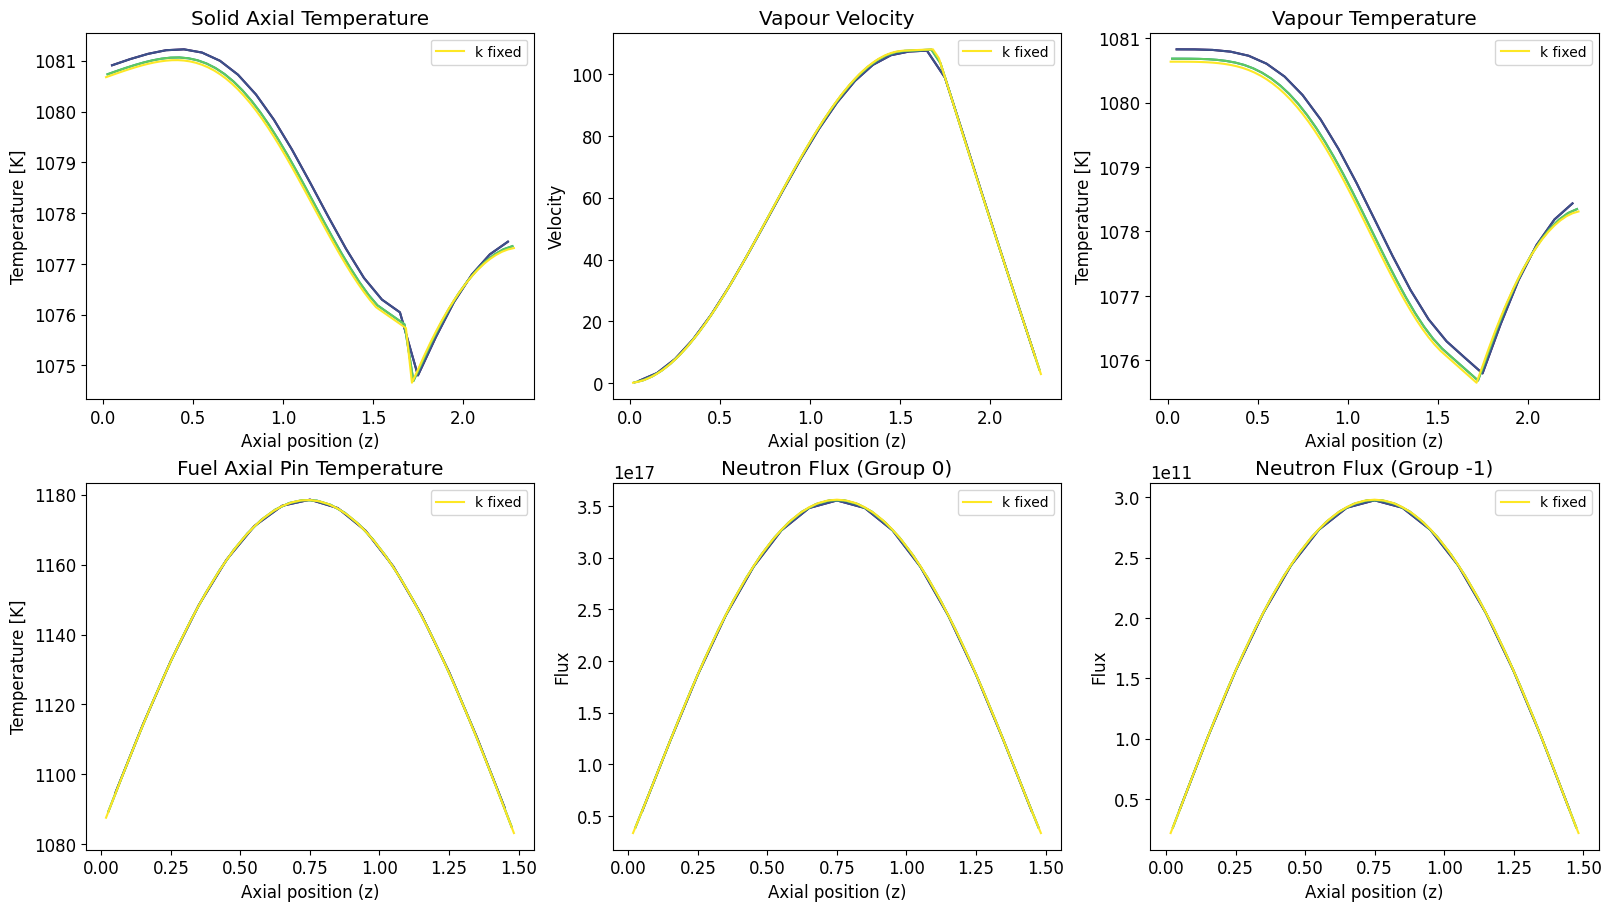

In [13]:
plot_reactor_solutions(solver)